**Q1.**

OK, a warm-up, just to get started.

1. Set up a grid of $K$ equally spaced values between 0 and 1, `{1/K, 2/K, ..., K/K}`.
2. Draw a point from the grid at random with equal probability.
3. For a very small $K$, repeat the above process `n = 5_000` times, and plot the ECDF of the draws.
4. What distribution does this approach as you increase $K$?

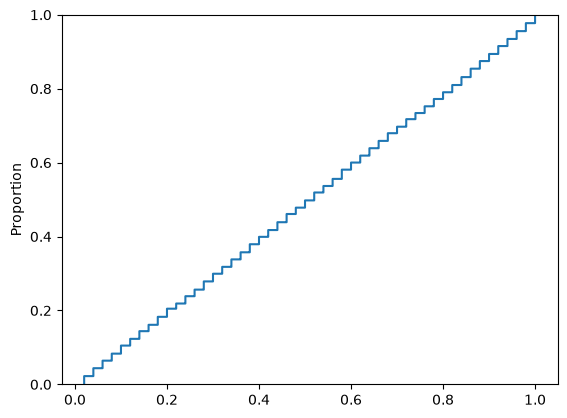

In [5]:
import numpy as np
import pandas as pd
from fractions import Fraction
import random
import seaborn as sns
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
#1
K = 50
grid = np.arange(1, K + 1) / K

#2
draw = rng.choice(grid)

#3
n = 5_000
samples = rng.choice(grid, size=n)
sns.ecdfplot(samples)
plt.show()

#4
# As K increases, this nears a uniform distribution


**Q2.** 

We often study sample averages: It's one of the first statistics you calculate for any dataset. What is the distribution of the sample mean?

1. Draw `n = 32` values from `Uniform[-sqrt(3), sqrt(3)]`; these are your data. The choice of $\pm \sqrt{3}$ ensures each draw has mean 0 and variance 1.
2. For this sample, compute the mean and multiply by `np.sqrt(n)`.
3. Repeat the above process `b = 5_000` times and plot the ECDF.
4. What distribution does this approach as $n$ increases?

-0.7757228046812641


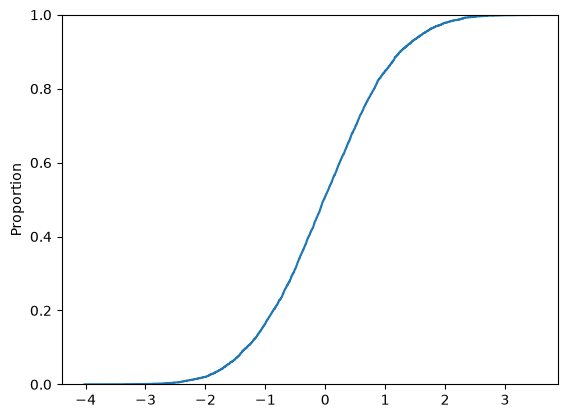

In [6]:
from scipy.stats import norm
n = 32
b = 5_000
lo = -np.sqrt(3)
hi =  np.sqrt(3)

# 1. 
sample = rng.uniform(lo, hi, size=n)

# 2.
stat = np.sqrt(n) * sample.mean()
print(stat)

# 3. 
samples = rng.uniform(lo, hi, size=(b, n))
stats = np.sqrt(n) * samples.mean(axis=1)
sns.ecdfplot(stats)
plt.show()

# 4. 

# As n increases, it approaches the standard normal distribution.

**Q3.** 

In reliability engineering, we are often concerned with the proportions of failures that occur. For example, the Challenger space shuttle exploded on January 28, 1986, when the primary and secondary o-rings failed. Floods often occur because too many levees or pumps are compromised. In this simulation, we have 40 units that each fail with probability $p$, and we want to study the distribution of the survivors. 

1. Flip `n = 40` coins, which each come up heads with probability $p = 1/2$ and tails with complementary probability.
2. From the final count of heads, subtract the expected number of heads, `n * p`.
3. Divide by the standard deviation `sqrt( n * p * (1-p) )`.
4. Repeat the above process `b = 5_000` times and plot the ECDF.
5. What distribution does this approach as $n$ increases?
6. How do the results change as you adjust $p$?

0.6324555320336759


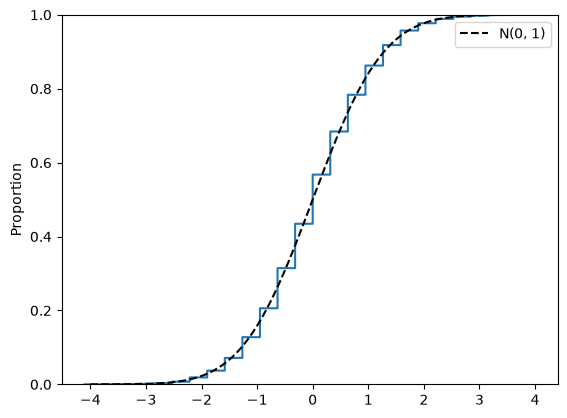

In [ ]:
n = 40
p = 0.5
b = 5_000

# 1.
flips = rng.random(n) < p
heads = flips.sum()

# 2.
centered = heads - n * p

# 3. 
z = centered / np.sqrt(n * p * (1 - p))
print(z)

# 4. 
heads = rng.binomial(n, p, size=b)
z = (heads - n * p) / np.sqrt(n * p * (1 - p))
sns.ecdfplot(z)

x = np.linspace(-4, 4, 200)
plt.plot(x, norm.cdf(x), "k--", label="N(0, 1)")
plt.legend()
plt.show()

# 5.
# As n increases it approaches the standard normal distribution.

# 6. 
# P nearing 0.5 gives a roughly symmetric distribution. Near 0, it is right-skewed. Near 1, it is left-skewed.


A process is running in discrete time. In each time interval of length `dt`, it terminates with probability `r * dt`, where `r * dt < 1`. This is called an arrival, death, or survival process, and is popular for modeling how long patients live after a procedure, whether an employee quits, or the arrival of the next goal in a sportsball match.

1. For each simulation of the process, determine the period in which termination occurs.
2. Convert periods to time by multiplying by `dt`.
3. Repeat the simulation `n = 5_000` times and plot the ECDF, for a value of `dt` close to zero (e.g. `dt = 1e-3`).
4. What distribution does this approach as $dt$ goes to zero?
5. How do the results change as you adjust $r$?

0.221


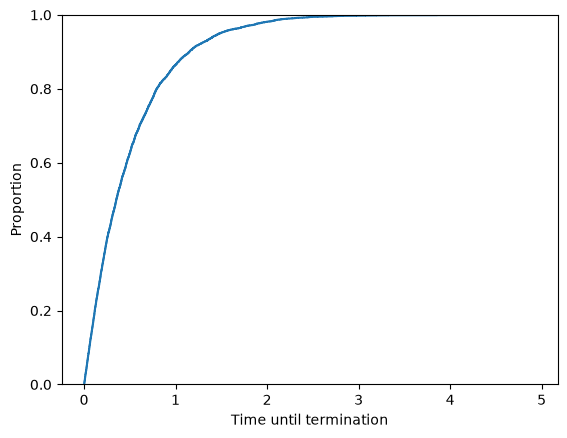

In [8]:
r = 2
dt = 0.001
n = 5_000

# 1.
period = rng.geometric(r * dt)

# 2
time = period * dt
print(time)

# 3
periods = rng.geometric(r * dt, size=n)
times = periods * dt
sns.ecdfplot(times)
plt.xlabel("Time until termination")
plt.show()

# 4. 
# As dt approaches 0, the distribution approaches an exponential distribution.

# 5.
# Increasing r gives shorter waiting times, so the ECDF rises faster.
# Decreasing r gives longer waiting times, so the ECDF rises slower.